### Steady state induction motor simulation.
 We aim to produce same results than Compumag TEAM problem 30a "https://www.compumag.org/jsite/images/stories/TEAM/problem30a.pdf"

We use same geometry with big surrounding airbox:

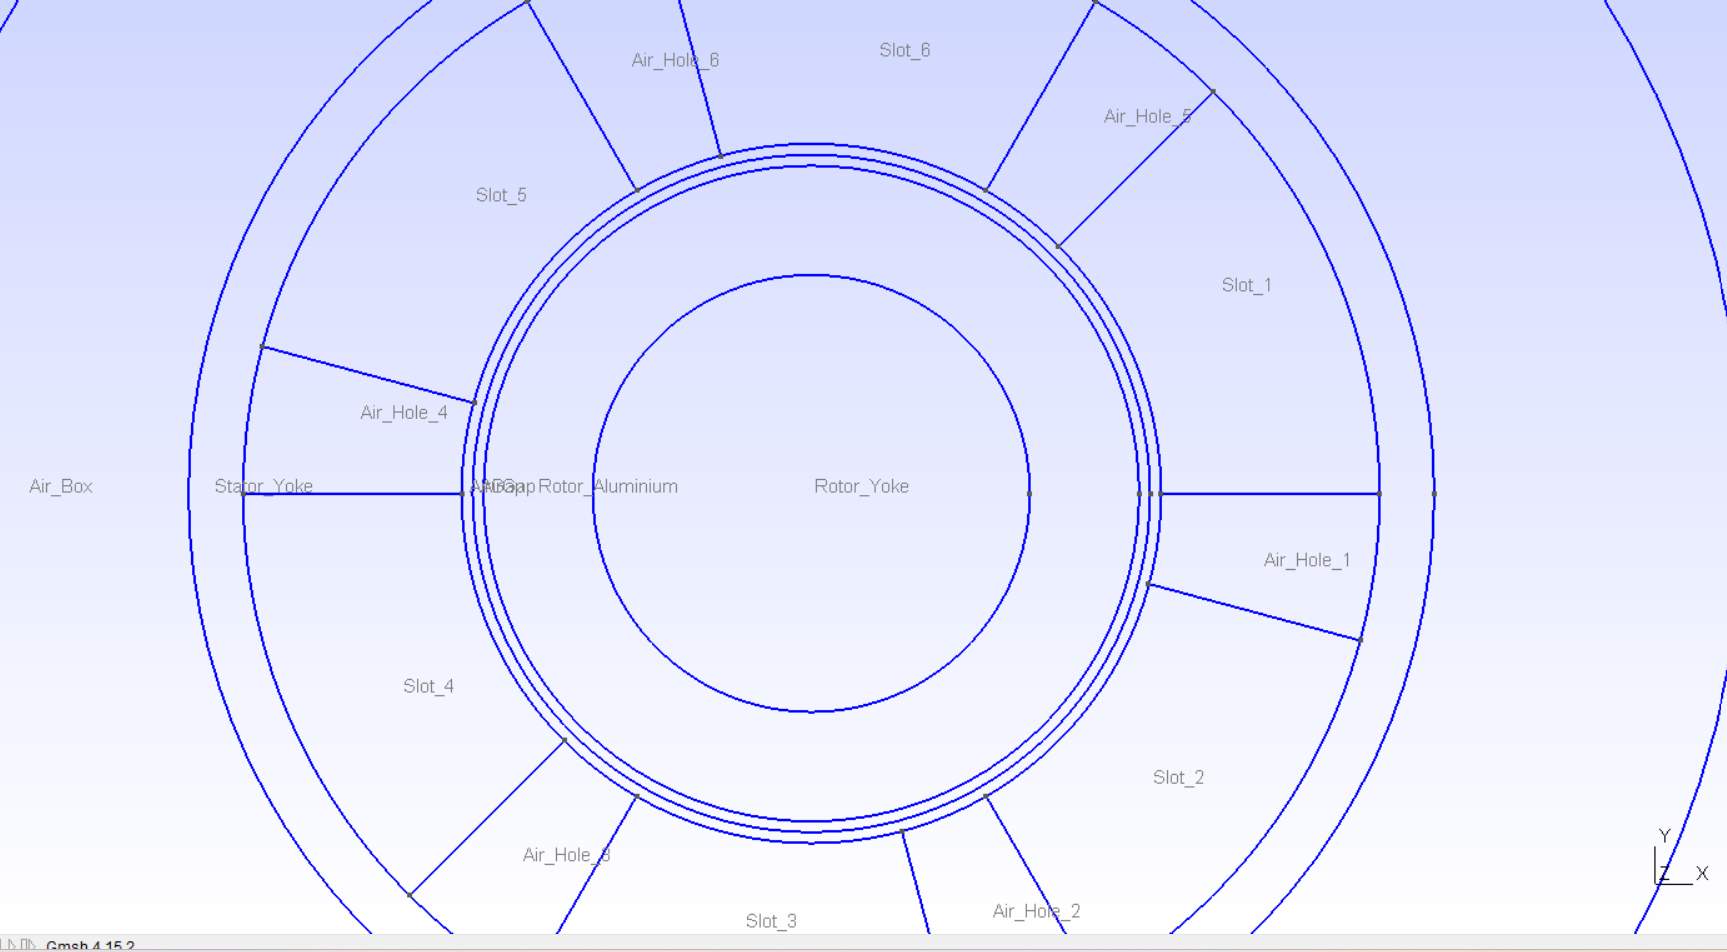


Failure to parse tags from meshio.


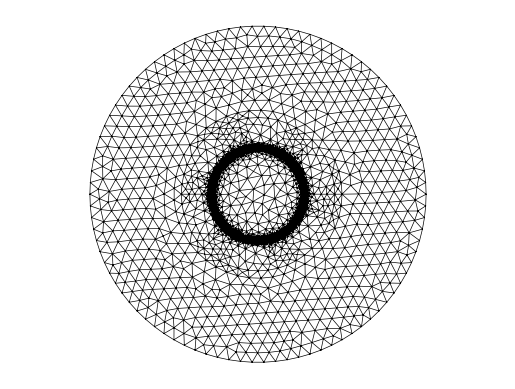

In [13]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

m = meshio.read("mesh/induction_motor.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()


In [14]:
from skfem import Basis, ElementTriP1

# Second order tringular elements.
e = ElementTriP1()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["Rotor_Yoke"])
basis_rotor_aluminium = basis.with_elements(mesh.subdomains["Rotor_Aluminium"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["Stator_Yoke"])
basis_air_box = basis.with_elements(mesh.subdomains["Air_Box"])
basis_air_holes = basis.with_elements(mesh.subdomains["Air_Hole"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

# Make FacetBasis for Maxwell Stress Tensor line integral in post-processing. Circe in the middle of airgap,
#  we use curved mesh in airgap so this construct is little awkward with compatibility between gmsh and scikit-fem...
"""
from skfem import FacetBasis
# MST line intgral path. Circe in the middle of airgap
r_mst = 0.031
facets = mesh.facets          # (2, nfacets) for MeshTri2: corner vertices
p = mesh.p

r0 = np.sqrt(p[0, facets[0]]**2 + p[1, facets[0]]**2)
r1 = np.sqrt(p[0, facets[1]]**2 + p[1, facets[1]]**2)

mst_facets = np.where(
    np.isclose(r0, r_mst, atol=1e-6) &
    np.isclose(r1, r_mst, atol=1e-6)
)[0]


fbasis = FacetBasis(mesh, basis.elem, facets=mst_facets)
"""

# Slot to phase current mapping
"""
Slot_1 → A-
Slot_6 → B+
Slot_5 → C-
Slot_4 → A+
Slot_3 → B-
Slot_2 → C+
"""
# Mapping dictionary
slot_bases = {
    name: basis.with_elements(mesh.subdomains[name])
    for name in mesh.subdomains
    if name.startswith("Slot_")
}

# For example Slot_1 → A+
print(slot_bases["Slot_1"])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases["Slot_1"])
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri2, ElementTriP1) object>
  Number of elements: 703
  Number of DOFs: 8258
  Size: 303696 B

In units of m:  0.0006597369865333222


Ampère's law is without considering displacement currents in low-frequencies:
 
$$

\nabla \times (\frac{1}{\mu} \nabla \times \mathbf{A})
=
\mathbf{J}_s + \mathbf{J}_e,
$$
 
where
 
- $\mathbf{J}_s$ is stator current,
- $\mathbf{J}_e$ is induced rotor current.

Induced current density can be represented with electric field in rotating frame as:

$$
\mathbf{J_e} = \sigma \mathbf{E} + \mathbf{v} \times \mathbf{B}
$$

In general, 

$$
\mathbf{E} = -\frac{\partial A_z}{\partial t} -\nabla V + \mathbf{v} \times \mathbf{B}
$$

and for our induction motor example, we can neglect the voltage term $\nabla V \approx 0$, since the eddy-currents in rotor bars are induced because of magnetic field, not by drived electric potential difference $\nabla V$

We get time-dependent term:

$$
\mathbf{J_e} =  \sigma (-\frac{\partial A_z}{\partial t}+\mathbf{v} \times \mathbf{B})
$$

The motiona term can written after opening few cross-products as:

$$
\mathbf{v} \times \mathbf{B} = -\omega y \frac{\partial A_z}{\partial x} + \omega x \frac{\partial A_z}{\partial y}
$$


The weak form of the magnetoquasistatic time-domain problem is


$$

\int_{\Omega}

\frac{1}{\mu} \, \nabla A_z \cdot \nabla v \
 + \int_{\Omega_c} \sigma \frac{\partial A_z}{\partial t}  v + \int_{\Omega_c} \sigma \omega (y \frac{\partial A_z}{\partial x} + x \frac{\partial A_z}{\partial y}) v \, d\Omega = \int_{\Omega_s} J_s v \, d\Omega

$$
with Dirichlet BC to surrounding air of A_z = 0 

After discretizing this into FEM formula and using backward-Euler, we get this:

$$

(\frac{\sigma \mathbf{M}}{\Delta t}+ (\mathbf{K}+\omega \sigma\mathbf{C})) \mathbf{A^{n+1}}= f +  \frac{\sigma \mathbf{M} A^n}{\Delta t}

$$
we can solve the next time step n+1 with the previous solution. C is now our motional term, K is stifness matrix and M is mass matrix





We assume only rotor aluminium and rotor steel are conducting regions wih $\sigma >> 0 $, so the frequency domain term is only present there. Otherwise the solving is really similar to our previuous tasks. Otherwise we are left with the time-independent solution.

In [33]:
from skfem import Functional

#######
# Material params
#######

# From compumag probelm configuration:
sigma_rotor_yoke = 1.6e6  # S/m
sigma_rotor_aluminium = 3.72e7  # S/m

mu0 = 4 * np.pi * 1e-7  # H/m
mu_rotor_yoke = 30 * mu0
mu_stator_yoke = 30 * mu0

#######
# Current params
#######

f = 60  # Hz
J_0 = 310e4

######
#  Bilinear and linear forms
######

# Bilinear mass matrix for transient problem
@BilinearForm
def mass_bilinear(A, v, w):
    return w.sigma*A*v

# Stifness matrix 
@BilinearForm
def stiff_bilinear(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

@BilinearForm
def motional_bilinear(A, v, w):
    # A = trial function (this is the unknown A_z), v = test function
    dAdx, dAdy = A.grad[0], A.grad[1]   # shape (nelems, nqp)

    x, y = w.x[0], w.x[1]                # global coordinates at quad points

    sigma = w.sigma                      # elementwise/quadrature conductivity

    # convective term: sigma*(x*dA/dy - y*dA/dx) * v
    return sigma * (x * dAdy - y * dAdx) * v


# Source currents
@LinearForm
def source_linear(v, w):
    return w.J * v

### Assemble left-hand-side

# RotorYoke and StatorYoke are modelled as magnetic iron
S_mat = stiff_bilinear.assemble(basis_rotor_yoke, mu=mu_rotor_yoke)
S_mat += stiff_bilinear.assemble(basis_stator_yoke, mu=mu_stator_yoke)

# Non magnetic regions have mu = mu0
S_mat += stiff_bilinear.assemble(basis_rotor_aluminium, mu=mu0)
S_mat += stiff_bilinear.assemble(basis_air_box, mu=mu0)
S_mat += stiff_bilinear.assemble(basis_air_holes, mu=mu0)
S_mat += stiff_bilinear.assemble(basis_air_gap, mu=mu0)

# Slots (non magnetic air with current density source) are modelled as non magnetic
for slot_basis in slot_bases.values():
    S_mat += stiff_bilinear.assemble(slot_basis, mu=mu0)

# Assemble mass matrix term for conducting region Rotor_Yoke and Rotor_Aluminium
M_mat = mass_bilinear.assemble(basis_rotor_yoke, sigma = sigma_rotor_yoke)
M_mat += mass_bilinear.assemble(basis_rotor_aluminium, sigma = sigma_rotor_aluminium)

angular_speed_start = 0
# Assemble base motional matrix ONCE (omega-independent, so reused every timestep)
C_mat_base = motional_bilinear.assemble(basis_rotor_yoke, sigma=sigma_rotor_yoke)
C_mat_base += motional_bilinear.assemble(basis_rotor_aluminium, sigma=sigma_rotor_aluminium)

# Assemble right-hand-side
dt = 2.5e-4
end_time = 0.8*1.5

A_init  =  0

A_prev =  np.ones(S_mat.shape[0]) * A_init

phase_shift = 0
A_phase = 0
B_phase = -2*np.pi/3
C_phase = -4*np.pi/3

all_time_values = []
all_Az_values = []
speeds = []
torques_arkkio = []
angles = []

t_vals = np.arange(0, end_time + dt, dt)
num_time_steps = len(t_vals)


torque_load = 0
rotor_inertia = 0.004716271998040877 # from COMSOL model

theta_mech_radian_start = 0

angular_speed = angular_speed_start
theta_mech_radian = theta_mech_radian_start

iteration = 1
for t in t_vals:

    # Stator is grid-connected: ALWAYS fixed supply frequency, never slip frequency
    J_A = J_0*np.cos(2*np.pi*f*t + A_phase + phase_shift)
    J_B = J_0*np.cos(2*np.pi*f*t + B_phase + phase_shift)
    J_C = J_0*np.cos(2*np.pi*f*t + C_phase + phase_shift)

    # Slot to phase current mapping
    """
    Slot_1 → A-
    Slot_6 → B+
    Slot_5 → C-
    Slot_4 → A+
    Slot_3 → B-
    Slot_2 → C+
    """


    phase_map = {
    "Slot_1": -J_A,
    "Slot_2": +J_C,
    "Slot_3": -J_B,
    "Slot_4": +J_A,
    "Slot_5": -J_C,
    "Slot_6": +J_B,
    }


    # Assign current to slot using our dictionary mapping
    b = 0
    for slot, J in phase_map.items():
        b += source_linear.assemble(slot_bases[slot], J=J)

    lhs = M_mat/dt + (S_mat + angular_speed*C_mat_base)   # <-- cheap, no assembly
    rhs = b + (M_mat @ A_prev)/dt

    lhs, rhs = enforce(lhs, rhs, D=mesh.boundary_nodes())
    A_next = solve(lhs, rhs)

    all_time_values.append(t)
    all_Az_values.append(A_next)

    mu0 = 4 * np.pi * 1e-7
    L_stack = 1.0        # your machine's axial stack length
    airgap_thickess = 2*1e-3 ## 2mm airgap          # inner/outer radius of the AirGap annulus
    @Functional
    def arkkio_integrand(w):
        gradA = w['A'].grad           # shape (2, nelems, nqp): [dA/dx, dA/dy]
        Bx = gradA[1]
        By = -gradA[0]
    
        x, y = w.x                    # global coordinates at quadrature points
        r = np.sqrt(x**2 + y**2)
        
        integrand = ((x*Bx + y*By)*(-y*Bx + x*By)/ r)
        return integrand

    integral = arkkio_integrand.assemble(
        basis_air_gap, A=basis_air_gap.interpolate(A_next)
    )
    torque_arkkio = (L_stack / (mu0 * (airgap_thickess))) * integral

    acceleration = (
        torque_arkkio - torque_load
    ) / rotor_inertia

    # 5. Advance mechanical state
    angular_speed = angular_speed + dt * acceleration
    theta_mech_radian = theta_mech_radian + dt * angular_speed

    speeds.append(angular_speed)
    torques_arkkio.append(torque_arkkio)
    angles.append(theta_mech_radian)

    
    print(f"{t}, going until {end_time}s,    iteratiom {iteration} / {num_time_steps}")
    iteration += 1

    A_prev = A_next




0.0, going until 1.2000000000000002s,    iteratiom 1 / 4802
0.00025, going until 1.2000000000000002s,    iteratiom 2 / 4802
0.0005, going until 1.2000000000000002s,    iteratiom 3 / 4802
0.00075, going until 1.2000000000000002s,    iteratiom 4 / 4802
0.001, going until 1.2000000000000002s,    iteratiom 5 / 4802
0.00125, going until 1.2000000000000002s,    iteratiom 6 / 4802
0.0015, going until 1.2000000000000002s,    iteratiom 7 / 4802
0.00175, going until 1.2000000000000002s,    iteratiom 8 / 4802
0.002, going until 1.2000000000000002s,    iteratiom 9 / 4802
0.0022500000000000003, going until 1.2000000000000002s,    iteratiom 10 / 4802
0.0025, going until 1.2000000000000002s,    iteratiom 11 / 4802
0.00275, going until 1.2000000000000002s,    iteratiom 12 / 4802
0.003, going until 1.2000000000000002s,    iteratiom 13 / 4802
0.0032500000000000003, going until 1.2000000000000002s,    iteratiom 14 / 4802
0.0035, going until 1.2000000000000002s,    iteratiom 15 / 4802
0.00375, going until

Torque: 4802
Speed: 4802
Time: 4802


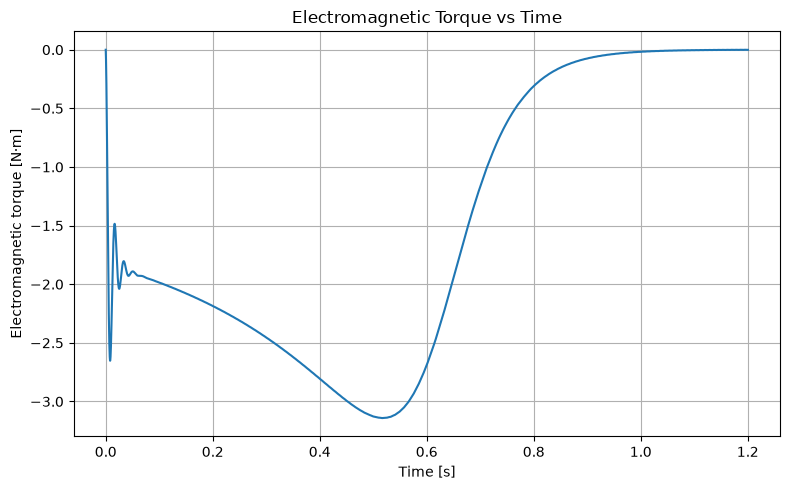

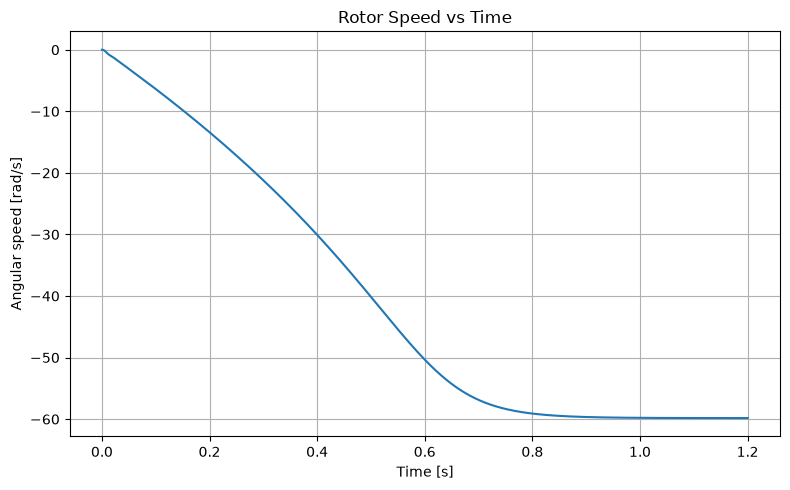

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
torques = np.asarray(torques_arkkio)
speeds = np.asarray(speeds)
time = np.asarray(t_vals)

# Make sure lengths match
print("Torque:", len(torques))
print("Speed:", len(speeds))
print("Time:", len(time))

# If your arrays contain one value per time step:
N = min(len(time), len(torques), len(speeds))

time_plot = time[:N]
torque_plot = torques[:N]
speed_plot = speeds[:N]

# -------------------------
# Torque vs time
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time_plot, torque_plot)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Electromagnetic torque [N·m]")
ax.set_title("Electromagnetic Torque vs Time")
ax.grid(True)

plt.tight_layout()
plt.show()


# -------------------------
# Speed vs time
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time_plot, speed_plot/(2*np.pi))  # conver to Hz

ax.set_xlabel("Time [s]")
ax.set_ylabel("Angular speed [rad/s]")
ax.set_title("Rotor Speed vs Time")
ax.grid(True)

plt.tight_layout()
plt.show()